# TWS Assignment: Applications of Terrestrial water storage (TWS) anomaly time series 
Authors: Kiana and Iniobong, Roelof, Rietbroek, Jan , 2024

# Instructions and assessment criteria

In the Jupyter notebook below you'll find marker cells after which you can fill out your answers.

There are 2 types of questions (14 in total) 

1. Type 1: **Code and Comment** questions which are preceded by

`Q01 [C&C] (e.g. 10 Pts)`

You'll get points for the code itself, but also for explaining **why** you've made your decisions on the coding.

or 

2. Type 2: Geophysical **interpretation questions** which are preceded by

`Q02 [INT] (e.g. 15pts)`


## Rules
1. The submission is an upload of your notebook through canvas, until the **17th of January 2025, 17:00**
2. You can split your answer into several cells, and use appropriate types where needed (e.g. code cells or markdown cells)
3. The use of tools such as chatgpt and github-copilot is discouraged but not forbidden. All individual sections which are generated with these tools should be explicitly indicated as such by the comment markers `#BEGIN ASSISTED` and `#END ASSISTED`. A global statement such as: `ChatGPT has been used as an aid in this exercise` is not allowed and will result in a fail. Using unmarked assisted code sections may result in a loss of points.
4. This is an individual assignment, but you're encouraged to brainstorm together
5. You'll need **55% of the total points** to pass.


## Links and Further Reading

- [Course page on Canvas](https://canvas.utwente.nl/courses/15004)
- The [shared folder on CRIB](https://platform.crib.utwente.nl/geospatial/user/rietbroekr/lab/tree/shared/Hydrological-and-Environmental-Cycles-2024-1B/Roelof_TWS/TerrestrialWaterStorage)

In [2]:
#Q00 (0 pts): FILL OUT YOUR NAME AND STUDENTNUMBER IN A CELL BELOW (0 Pts)

# Introduction and goal of the assignment

In this assignment, we will learn how to use the global grid-based TWS time series derived from GRACE observations (the output of the Tutorial) to track changes in stored water in different regions of continents. To achieve this, we define our regions of interest as basins. A basin is a land area where all water drains to a common point, such as a river or lake. It is like a natural bowl that collects water.

An example of this is the Nile Basin, located in northeastern Africa and primarily centered around the Nile River, which flows from south to north through the continent.

<div style="text-align: center;">
    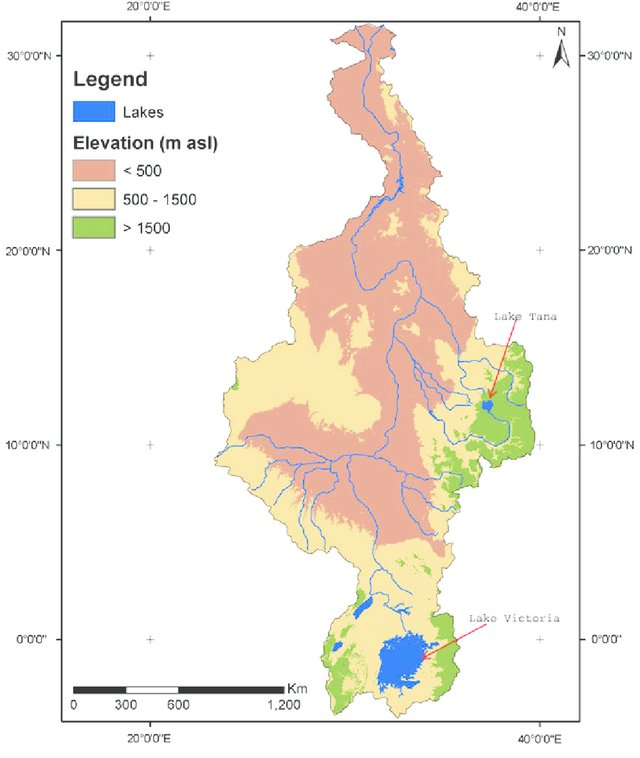
</div>


Source: Berhanu, B., et al. (2015). Upstream–Downstream Linkages of Hydrological Processes in the Nile River Basin.

In the map shown below, the locations of the Nile Basin and several other major basins across different continents are represented. The names of the basins, including the Mississippi River, Amazonas, Parana, Congo, Lake Chad, Ganges, Indus and Greenland are labeled on the map over their respective land areas.


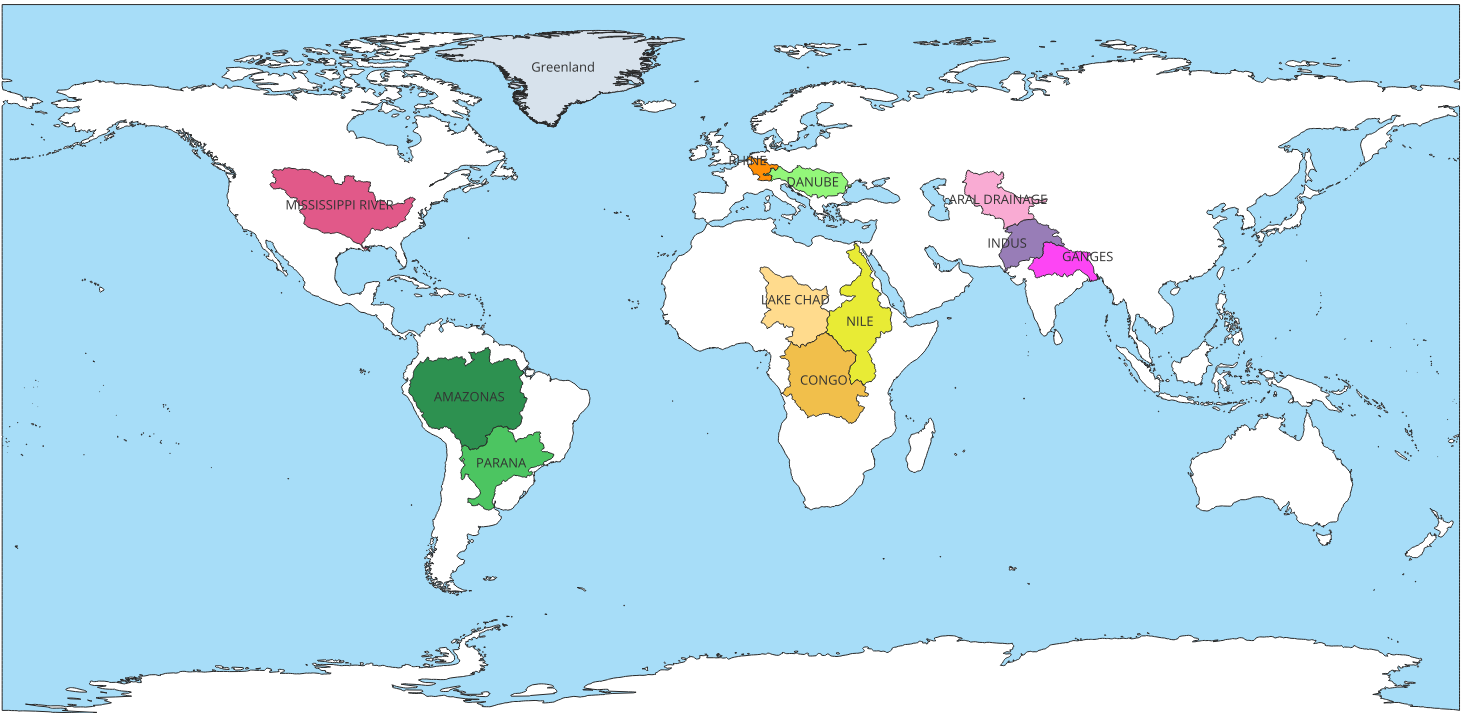

To access these basins for TWS analysis, we work with spatial datasets, such as those in the GeoPackage format. These datasets can be utilized in GIS software like QGIS.

In this assignment, the GeoPackage data is provided by Global Runoff Data Centre (GRDC), which offers watershed and drainage basin boundaries. link: https://www.kliwas.de/SharedDocs/ExterneLinks/GRDC/mrb_shp_zip.html

---
## Analyzing TWS anomaly time series in basins helps us to:

1. Monitor water availability and groundwater depletion (e.g., for agriculture and drinking)
2. Detect droughts or floods
3. Study the impacts of climate change on water resources 

By monitoring changes in the TWS time series for a chosen basin, we can understand how the amount of stored water has changed over time, which allows us to track water availability, identify potential droughts or floods, and assess the impacts of climate change on water resources.

After completing this assignment, you have calculated the TWS anomaly time series for three basins.

#### Start processing 
---

## Q00 (0 pts) Copy and rename this Jupyter notebook so that your name and student number is in the file name. Furthermore, make sure you enter your details in the cell below

<!-- modify to your answer Q00-->
# Submitter
Student name: **John Doe**

Student number **1234567**

Date:

## Q01 [C&C] (5 Pts): Load the necessary python modules and explain their role in the notebook

In [1]:
# your answer

## Q02 [C&C] (5 Pts): Load global Total Water anomaly time series from 'TWS.nc' file

##### Load the tws time series (the output of the tutorial)

In [2]:
#your answer

In order to obtain the TWS anomaly time series in a basin, we generate grid points for each basin that have the same spatial resolution as the grid-based TWS anomaly time series obtained from the tutorial. As an example, the picture below shows the gridded TWS anomaly values in 2002-04-15 in a region on Earth with a latitude range of [3,29] and a longitude range of [5,27], including the LAKE CHAD basin. 

<div style="text-align: center;">
    <img src="attachments/congo.png"" alt="Congo" width="550px">
</div>

Suppose we exclude the grid cells that are outside the boundary of the basin and only consider the grid cells inside the basin. In that case, we will have the TWS anomaly time series for each grid cell inside the basin in the period of 2002- 2017 based on the global TWS anomaly time series.

Therefore, to analyze the TWS anomaly time series for our selected basins, we first need to load the basin GeoPackage data, which provides their geographic location and boundaries of our watersheds.

## Q03 [C&C] (5 pts): Load basin geospatial polygons from GeoPackage files
### Hints & Tips

- Use a variable to hold the correct folder path (e.g. `data_dir`) to ensure that GeoPackage files can be accessed.
- Use tools like `geopandas` to ensure the GeoPackage files are compatible with your analysis.

In [4]:
# your answer

Considering the spatial resolution of the global TWS anomaly time series (1×1 degree), we identify the latitude and longitude of the grid points within each basin boundary with the exact spatial resolution as the global TWS anomaly dataset. Also, it is possible to choose a higher spatial resolution than 1*1 degrees.

## Helper Function to generate basin points for each basin
The following function can be used in your code to generate a mask of gridded points from your basin polygon

In [25]:
""" 
Use basin_grid_points function to generate grid points inside the boundries of basins.

This function takes three input parameters as follows: 
1- Basins in a pandas GeoDataframe
2- Resolution = spacing between grid points in degree
3- Buffer = dist from the edge of basin in degree. We define bufer value to capture the whole locations of basins, because the shapes of basins are not regular

Output:
This function converts the basin shapes into grid points (latitude and longitude) with a given resolution and buffer and returns the gridpoints inside the basins in a xarray
dataset format
"""



def basin_grid_points(basin, resolution, buffer):

    Basin_names = [] # Create an empty list to store the basins names 
    

    for index in range(len(basin.geometry)):
        geom= basin.geometry.loc[index]                         # Basins can have one shape (Polygon) or multiple disconnected shapes (MultiPolygon)
        if geom.geom_type == "Polygon":                         # Define a if statement and extract the border coordinates if basin shape is polygon
            points = np.array(geom.exterior.coords[:-1])        # Extract all coordinates of the borders of a basin
            Basin_name = basin["name"][0] 

            # Create a Grid
            x_min, x_max = int(np.min(points[:, 0])) - buffer, int(np.max(points[:, 0])) + buffer
            y_min, y_max = int(np.min(points[:, 1])) - buffer, int(np.max(points[:, 1])) + buffer

        elif geom.geom_type == "MultiPolygon": ## Extract the border coordinates if basin shape is multipolygonpolygon
            
            # A multipolygon consists of polygons. So we create an empty list to store the coordinates of each basin's borders together with other basins
        
            all_points = []  # Create an empty list
            for polygon in geom.geoms:
                points = np.array(polygon.exterior.coords[:-1])  
                all_points.extend(points)

            all_points = np.array(all_points) # borders coordinates for all polygons of multi polygon
            Basin_name = basin["name"][0]

       #Create a Grid:
    
            x_min, x_max = int(np.min(all_points[:, 0])) - buffer, int(np.max(all_points[:, 0])) + buffer
            y_min, y_max = int(np.min(all_points[:, 1])) - buffer, int(np.max(all_points[:, 1])) + buffer


        x = np.arange(x_min, x_max, resolution)
        y = np.arange(y_min, y_max, resolution)


        X, Y = np.meshgrid(x, y)


        grid_points = np.column_stack([X.ravel(), Y.ravel()]) ## Now we have the Grid
        
        
        ## Filter the grid points to have only the grid points which are inside the basin's boundary
        mask1 = contains(geom, grid_points[:, 0], grid_points[:, 1])
        inside_points = grid_points[mask1] 

        Basin_names.append(Basin_name) 
        

        #Convert the filtered points into an xarray dataset
        ds_basin = xr.Dataset(coords = dict(lat = ("lat", inside_points[:,1]), lon = ("lon", inside_points[:,0]), basin=("basin", Basin_names)))
        


        return ds_basin # Return the output of the function

# Q04 [C&C] (10Pts): Create masks for all basins

In [5]:
# your answer

# The next step will be to select a basin and compute the TWS time series for each grid cell in the selected basin

At this step, by knowing the coordinates of the grid points within each basin and having access to the global grid-based TWS time series (i.e., the dsgrd xarray dataset), we can compute the TWS time series for each grid cell within the basin.

## Q06 [C&C] (20Pts) Make a function which calculates TWS time series for each grid cell within a certain basin mask

In [6]:
# your answer

At this step, we have a TWS anomaly time series for each grid cell with a size of 1*1 degrees in latitude and longitude. The picture below illustrates the gridded TWS anomaly time series for each grid cell in the Lake Chad basin. 

<div style="text-align: center;">
<img src="attachments/grid_tws.png", alt="Gridded TWS"  width="800px">
</div>

# The next step will be to compute the weighted mean TWS time series for the selected basin

Since basins cover large areas with many grid cells, each containing its own TWS time series data, we need to combine the data to understand how the total water stored in the basin has changed over time.

To achieve this, we calculate the average of TWS anomaly values across all grid cells within the basin for each month. This process is known as spatial averaging. Considering the entire period from 2002 to 2017, spatial averaging will provide a single TWS time series for the whole of the basin each month, allowing us to track overall changes in water storage over time.

The equation of the spatial averaging can be written as:


$$
\overline{\text{TWS}} = \frac{1}{N} \sum_{i=1}^{N} \text{TWS}_i
$$

Where:
- $\overline{\text{TWS}}$ is the spatially averaged TWS anomaly for the basin.
- $N$ is the total number of grid cells within the basin.
- $\text{TWS}_i$ is the TWS anomaly value for the $i$-th grid cell within the basin.



Alternatively, applying a weighted average depending on factors like distance or significance of each point can provide a more accurate and representative calculation of the average value.

The equation for weighted spatial averaging is:

$$
\overline{\text{TWS}} = \frac{\sum_{i=1}^{N} w_i \cdot \text{TWS}_i}{\sum_{i=1}^{N} w_i}
$$

Where:
- $\overline{\text{TWS}}$ is the weighted spatially averaged TWS anomaly for the basin.
- $N$ is the total number of grid cells within the basin.
- $\text{TWS}_i$ is the TWS anomaly value for the $i$-th grid cell within the basin.
- $w_i$ is the weight assigned to the $i$-th grid cell, often based on its area or another relevant factor.



In this exercise, we calcualte the weighted average based on grid cell areas as decribed as below:


The Earth is a sphere, and as you move away from the equator toward the poles, the distance between lines of longitude decreases (see picture below). Because of this, grid cells near the poles have smaller areas than grid cells near the equator. To account for variations in grid cell size we consider a weighted average based on latitude. This weighting allows us to consider area differences by assigning more weight to grid cells near the equator, which have larger areas.


<div style="text-align: center;">
    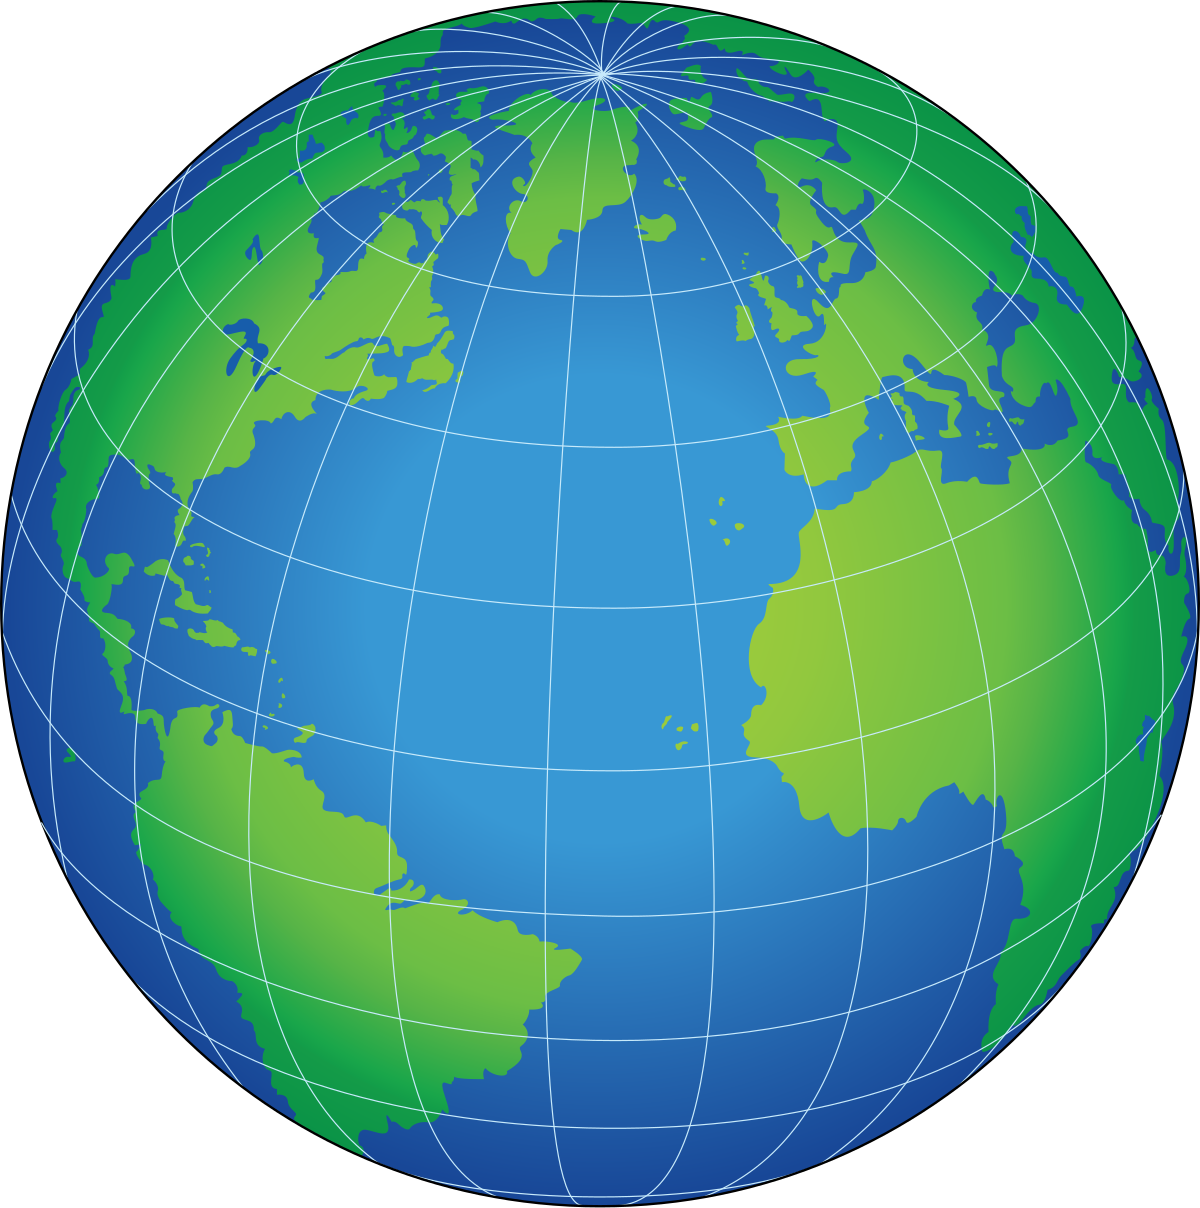
</div>


Source : https://en.wikipedia.org/wiki/Discrete_global_grid

## Q07 [C&C] (10Pts) Design a function which computes the weighted mean TWS time series for a given basin

In [7]:
#your answer

## Q08 [C&C] (10 Pts) Plot Weighted Mean TWS for three selected basins of your choice

In [8]:
# your answer

## Q09 [C&C] (12 Pts): Plot TWS time series for the 12 basins arranged in 4 rows and three columns. Each plot should display the TWS time series for one basin

In [9]:
# your answer

# Geophysical interpretation

## Q10 [INT] (30 Pts)- Explain what you see in the time series of your chosen 3 basins. Do you notice any differences between the locations? Try to find an explanation and evidence for what you are seeing




*YOUR ANSWER*

## Q11 [INT] (10 pts) - Can you think of another application of the TWS time series at another location? Explain the importance of the application in light of research and/or other stakeholders

*YOUR ANSWER*

## Q12 [INT] (10 Pts) - What additional processing steps would you need to extract groundwater variations from TWS time series?

*YOUR ANSWER*

## Q13 [INT] (10 Pts) - In which basin do you expect the largest errors? What type of errors can be introduced in the time series. Also explain how these errors are affected by the applied spatial filtering

*YOUR ANSWER*

## Q14 [INT] (5 Pts) - How would the TWS errors be affected if GRACE would have flown at a lower altitude? why?

*YOUR ANSWER*

## Further reading

To better understand and support your answers for Step 10, you can refer to the following resources for each basin:

### Amazon
- [Hydrology and Earth System Sciences (2019)](https://hess.copernicus.org/articles/23/2841/2019/)

### Greenland
- [GRACE: Greenland Ice Loss (2002–2021)](https://grace.jpl.nasa.gov/resources/30/greenland-ice-loss-2002-2021/)
- [ScienceDirect: Greenland Study](https://www.sciencedirect.com/science/article/pii/S0034425724000051)

### Mississippi River
- [ScienceDirect: Mississippi River Study](https://www.sciencedirect.com/science/article/pii/S0022169423011745)

### Parana
- [AGU Publications: Parana River Basin](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016GL069538)

### Ganges Basin
- [ScienceDirect: Ganges Basin Analysis](https://www.sciencedirect.com/science/article/pii/S0022169424009879)

### Nile
- [MDPI: Nile Basin Study](https://www.mdpi.com/2072-4292/13/4/651)

### Congo
- [ScienceDirect: Congo Basin Study](https://www.sciencedirect.com/science/article/pii/S2214581823002501)

### Lake Chad
- [ScienceDirect: Lake Chad Study (1)](https://www.sciencedirect.com/science/article/abs/pii/S0022169416303456)
- [Springer: Lake Chad Study (2)](https://link.springer.com/article/10.1007/s11600-019-00260-y)
- [ScienceDirect: Lake Chad Study (3)](https://www.sciencedirect.com/science/article/pii/S0309170815300026)
### Indus
- [ScienceDirect: Indus Basin Study](https://www.sciencedirect.com/science/article/pii/S0048969721044399)

---